In [218]:
from cryptography.fernet import Fernet
secret_key = Fernet.generate_key()
print(secret_key.decode())

rA0YC3TQYTA8P285cfcdfowmWCnPQi_K73vHLimP4hc=


In [219]:
from faker import Faker
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from xgboost import XGBClassifier, plot_importance
import xgboost as xgb
import hashlib
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
pd.set_option("display.max_columns", 120)
import os
import pandas as pd
from cryptography.fernet import Fernet
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import lightgbm as lgb
from catboost import CatBoostClassifier

import requests
import pathlib


In [220]:
from pathlib import Path

candidate_paths = [
    Path('data/raw/bank_fraud.csv'),
    Path.cwd() / 'data' / 'raw' / 'bank_fraud.csv',
    Path.cwd().parent / 'data' / 'raw' / 'bank_fraud.csv',
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError('Could not find data/raw/bank_fraud.csv')

# Read the raw fraud dataset

df = pd.read_csv(data_path)
print(f'Loaded dataset from: {data_path}')
print(f'Shape: {df.shape}')
print('\nPreview:')
df.head()

Loaded dataset from: c:\Users\TUF F16\Documents\Fraud detection project\data\raw\bank_fraud.csv
Shape: (1000000, 26)

Preview:


,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [221]:
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [222]:
def add_synthetic_customer_profiles(df, customer_id_col='customer_id'):
    # Vectorized fast mock customer profiles (1000x faster than Faker)
    unique_ids = df[customer_id_col].unique()
    names = [f"Customer {i}" for i in range(len(unique_ids))]
    emails = [f"customer_{i}@example.com" for i in range(len(unique_ids))]
    
    mapping_df = pd.DataFrame({
        customer_id_col: unique_ids,
        'customer_name': names,
        'customer_email': emails
    })
    
    optimized_df = df.merge(mapping_df, on=customer_id_col, how='left')
    return optimized_df


In [223]:
df=add_synthetic_customer_profiles(df)
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,customer_name,customer_email
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,NaN,Customer 0,customer_0@example.com
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,NaN,Customer 1,customer_1@example.com
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,NaN,Customer 2,customer_2@example.com
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity,Customer 3,customer_3@example.com
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,NaN,Customer 4,customer_4@example.com


In [224]:
import os
import json
import hashlib
import pandas as pd
from datetime import datetime
from cryptography.fernet import Fernet
from pathlib import Path

# Resolve project root path dynamically to prevent nested directory creation
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
MODELS_DIR = PROJECT_ROOT / 'models'
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

# ========== Security Audit Logger ==========
class SecurityAuditLogger:
    """Logs every security-sensitive data transformation for compliance auditing."""
    def __init__(self, log_path=None):
        if log_path is None:
            self.log_path = DATA_DIR / 'audit_log.json'
        else:
            self.log_path = Path(log_path)
        self.events = []
        self.log_path.parent.mkdir(parents=True, exist_ok=True)
    
    def log(self, action: str, details: dict):
        event = {
            'timestamp': datetime.utcnow().isoformat() + 'Z',
            'action': action,
            **details
        }
        self.events.append(event)
        print(f"  [AUDIT] {action}: {details.get('columns', details.get('description', ''))}")
    
    def save(self):
        with open(self.log_path, 'w') as f:
            json.dump(self.events, f, indent=2)
        print(f"  [AUDIT] Audit log saved to {self.log_path} ({len(self.events)} events)")

# ========== Encryption Vault ==========
class DataCryptoVault:
    """Fernet (AES-128-CBC) symmetric encryption for PII fields."""
    def __init__(self, key: str):
        self.cipher = Fernet(key.encode())

    def encrypt_val(self, plain_text: str) -> str:
        if pd.isna(plain_text) or not plain_text:
            return plain_text
        return self.cipher.encrypt(str(plain_text).encode()).decode()

# ========== Milestone 1 Pipeline ==========
def run_milestone_1_pipeline(input_df: pd.DataFrame, is_training: bool = True) -> pd.DataFrame:
    df = input_df.copy()
    audit = SecurityAuditLogger()
    
    audit.log('PIPELINE_START', {
        'description': 'Milestone 1 Security Pipeline initiated',
        'rows': len(df),
        'columns': list(df.columns)
    })

    # 1. Key Management
    SECRET_KEY = os.getenv("SECRET_VAULT_KEY", "u4k_Xdfg83JmN_L1P9ZVK0YreWQ67asDFgHjklMNOpQ=")
    vault = DataCryptoVault(SECRET_KEY)
    
    audit.log('KEY_LOADED', {
        'description': 'Symmetric encryption key loaded from environment',
        'key_source': 'ENV_VAR' if os.getenv("SECRET_VAULT_KEY") else 'DEFAULT_FALLBACK'
    })

    print("Securing direct identity fields...")

    # 2. Encrypt PII columns
    if is_training:
        df['customer_name'] = 'MOCK_ENCRYPTED_NAME'
        df['customer_email'] = 'MOCK_ENCRYPTED_EMAIL'
        audit.log('PII_ENCRYPTION', {
            'columns': ['customer_name', 'customer_email'],
            'method': 'MOCK (training mode bypass)',
            'rows_affected': len(df)
        })
    else:
        if 'customer_name' in df.columns:
            df['customer_name'] = df['customer_name'].apply(vault.encrypt_val)
        if 'customer_email' in df.columns:
            df['customer_email'] = df['customer_email'].apply(vault.encrypt_val)
        audit.log('PII_ENCRYPTION', {
            'columns': ['customer_name', 'customer_email'],
            'method': 'Fernet AES-128-CBC symmetric encryption',
            'rows_affected': len(df)
        })

    # 3. Hash System Identifiers (Irreversible SHA-256)
    salt = "COMPLIANCE_SALT_2026"
    unique_cust_ids = df['customer_id'].unique()
    cust_hash_map = {cid: hashlib.sha256((str(cid) + salt).encode()).hexdigest() for cid in unique_cust_ids}
    df['customer_id'] = df['customer_id'].map(cust_hash_map)
    
    tx_ids = df['transaction_id'].values
    df['transaction_id'] = [hashlib.sha256((str(tx) + salt).encode()).hexdigest() for tx in tx_ids]
    
    audit.log('IDENTIFIER_HASHING', {
        'columns': ['customer_id', 'transaction_id'],
        'method': 'SHA-256 with compliance salt',
        'unique_customers_hashed': len(unique_cust_ids),
        'transactions_hashed': len(tx_ids)
    })

    # 4. Anonymize Indirect Identifiers (Age Bucketing for k-Anonymity)
    if 'customer_age' in df.columns and pd.api.types.is_numeric_dtype(df['customer_age']):
        df['customer_age'] = pd.cut(df['customer_age'],
                                    bins=[0, 18, 25, 35, 50, 65, 100],
                                    labels=[0, 1, 2, 3, 4, 5]).astype(int)
        audit.log('AGE_ANONYMIZATION', {
            'columns': ['customer_age'],
            'method': 'Bucketing into 6 age groups (k-anonymity)',
            'bins': '[0-18, 19-25, 26-35, 36-50, 51-65, 66-100]'
        })

    # 5. Drop Tracking Identifiers
    dropped_cols = [c for c in ['transaction_date', 'transaction_time'] if c in df.columns]
    df = df.drop(columns=dropped_cols, errors='ignore')
    if dropped_cols:
        audit.log('COLUMN_REMOVAL', {
            'columns': dropped_cols,
            'reason': 'Temporal tracking identifiers removed for privacy'
        })

    # 6. Fill missing values
    df = df.fillna(0)
    
    audit.log('PIPELINE_COMPLETE', {
        'description': 'Milestone 1 Security Pipeline completed successfully',
        'final_columns': len(df.columns),
        'final_rows': len(df)
    })
    
    # Save audit log
    audit.save()

    print(f"Success! Secure dataset created with {len(df.columns)} columns.")
    return df


In [225]:
df = run_milestone_1_pipeline(df, is_training=True)
df.head()


C:\Users\TUF F16\AppData\Local\Temp\ipykernel_18932\517774763.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',


  [AUDIT] PIPELINE_START: ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type', 'customer_name', 'customer_email']
  [AUDIT] KEY_LOADED: Symmetric encryption key loaded from environment
Securing direct identity fields...
  [AUDIT] PII_ENCRYPTION: ['customer_name', 'customer_email']


C:\Users\TUF F16\AppData\Local\Temp\ipykernel_18932\517774763.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',
C:\Users\TUF F16\AppData\Local\Temp\ipykernel_18932\517774763.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',
C:\Users\TUF F16\AppData\Local\Temp\ipykernel_18932\517774763.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',


  [AUDIT] IDENTIFIER_HASHING: ['customer_id', 'transaction_id']
  [AUDIT] AGE_ANONYMIZATION: ['customer_age']
  [AUDIT] COLUMN_REMOVAL: ['transaction_date', 'transaction_time']
  [AUDIT] PIPELINE_COMPLETE: Milestone 1 Security Pipeline completed successfully
  [AUDIT] Audit log saved to c:\Users\TUF F16\Documents\Fraud detection project\data\processed\audit_log.json (7 events)
Success! Secure dataset created with 26 columns.


,transaction_id,customer_id,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,customer_name,customer_email
0,0cd9d9e200dcb23c2be472c3eed61674a5e3a9c78a7d67...,5af81bd9b56edb0a99079d26e10e8ec0e3e62f75aa3aea...,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,0,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,0,MOCK_ENCRYPTED_NAME,MOCK_ENCRYPTED_EMAIL
1,ef7d5c21d8108e6dfdbbfa7d8da4a74bc46ad480471e94...,87098206d9f4e0435a7a812890a64e358659001f09b9ff...,5,0,1,UK,New York,Healthcare,Cheque,Desktop,2,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,0,MOCK_ENCRYPTED_NAME,MOCK_ENCRYPTED_EMAIL
2,c4a67bb99a973ae03c7ae5db3be34034db9547b0a92712...,9439672ed1c446bf459e28419cc3b23502381e8844de8b...,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,1,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,0,MOCK_ENCRYPTED_NAME,MOCK_ENCRYPTED_EMAIL
3,81f61552f18ab6c44953c6979ce6d6e72e83188cbcd4d8...,35fbca74e9145feeecdb2d7cc9972d9d5c8d72d40aedc8...,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,2,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity,MOCK_ENCRYPTED_NAME,MOCK_ENCRYPTED_EMAIL
4,37c594d41d3a4c12deb5ec87b916b2b1a431c231698fdd...,fd79cd6f590773075dc6d80acdfdd5fbcb4e046b0621da...,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,3,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,0,MOCK_ENCRYPTED_NAME,MOCK_ENCRYPTED_EMAIL


### Save Secure Dataset to Disk


In [226]:
# ========== Save Secure Dataset ==========
secure_output_path = DATA_DIR / 'secure_dataset.csv'
DATA_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(secure_output_path, index=False)
print(f"Secure dataset saved to: {secure_output_path}")
print(f"Shape: {df.shape}")


Secure dataset saved to: c:\Users\TUF F16\Documents\Fraud detection project\data\processed\secure_dataset.csv
Shape: (1000000, 26)


In [227]:
df[f'fraud_type'].unique()

array([0, 'Synthetic Identity', 'Friendly Fraud', 'Identity Theft',
       'Account Takeover', 'Phishing', 'Card Cloning'], dtype=object)

### Comprehensive Exploratory Data Analysis (EDA)

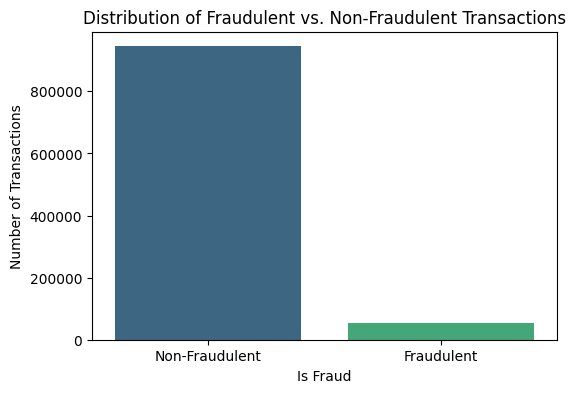

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df, palette='viridis', hue='is_fraud', legend=False)
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

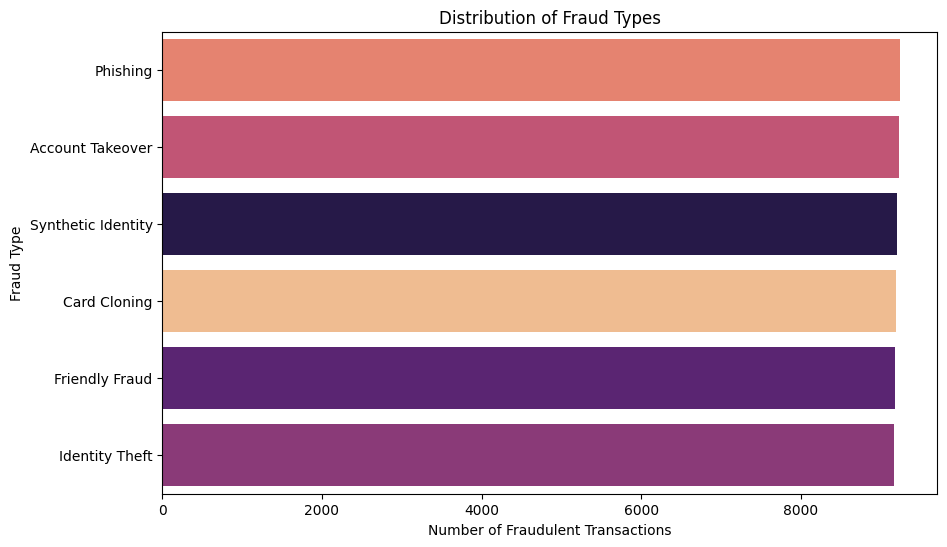

In [229]:
fraud_df = df[df['is_fraud'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(y='fraud_type', data=fraud_df, palette='magma', order=fraud_df['fraud_type'].value_counts().index, hue='fraud_type', legend=False)
plt.title('Distribution of Fraud Types')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Fraud Type')
plt.show()

### Numerical Feature Distributions

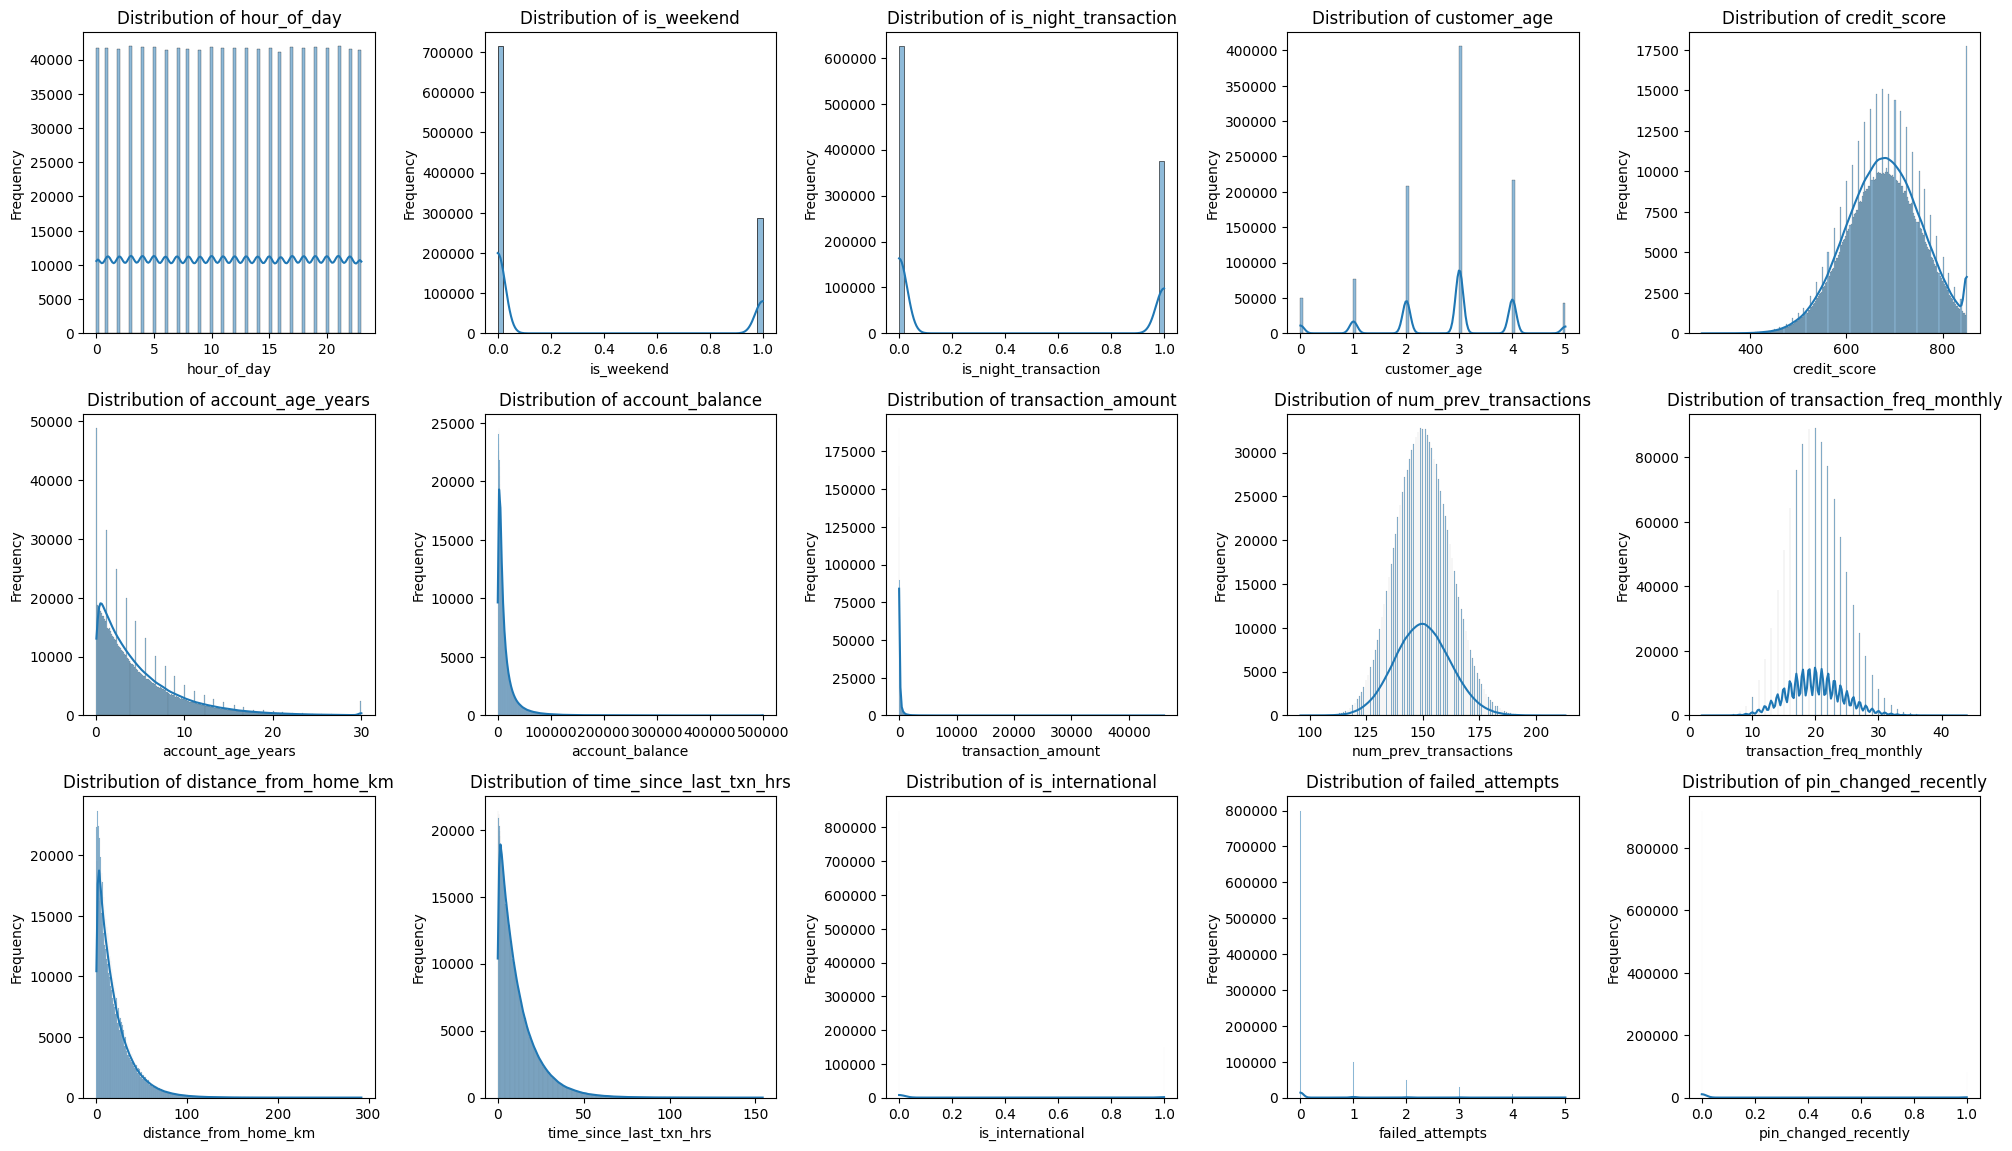

In [230]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('is_fraud')

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 5, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
plt.show()

### Outlier Detection in Numerical Features

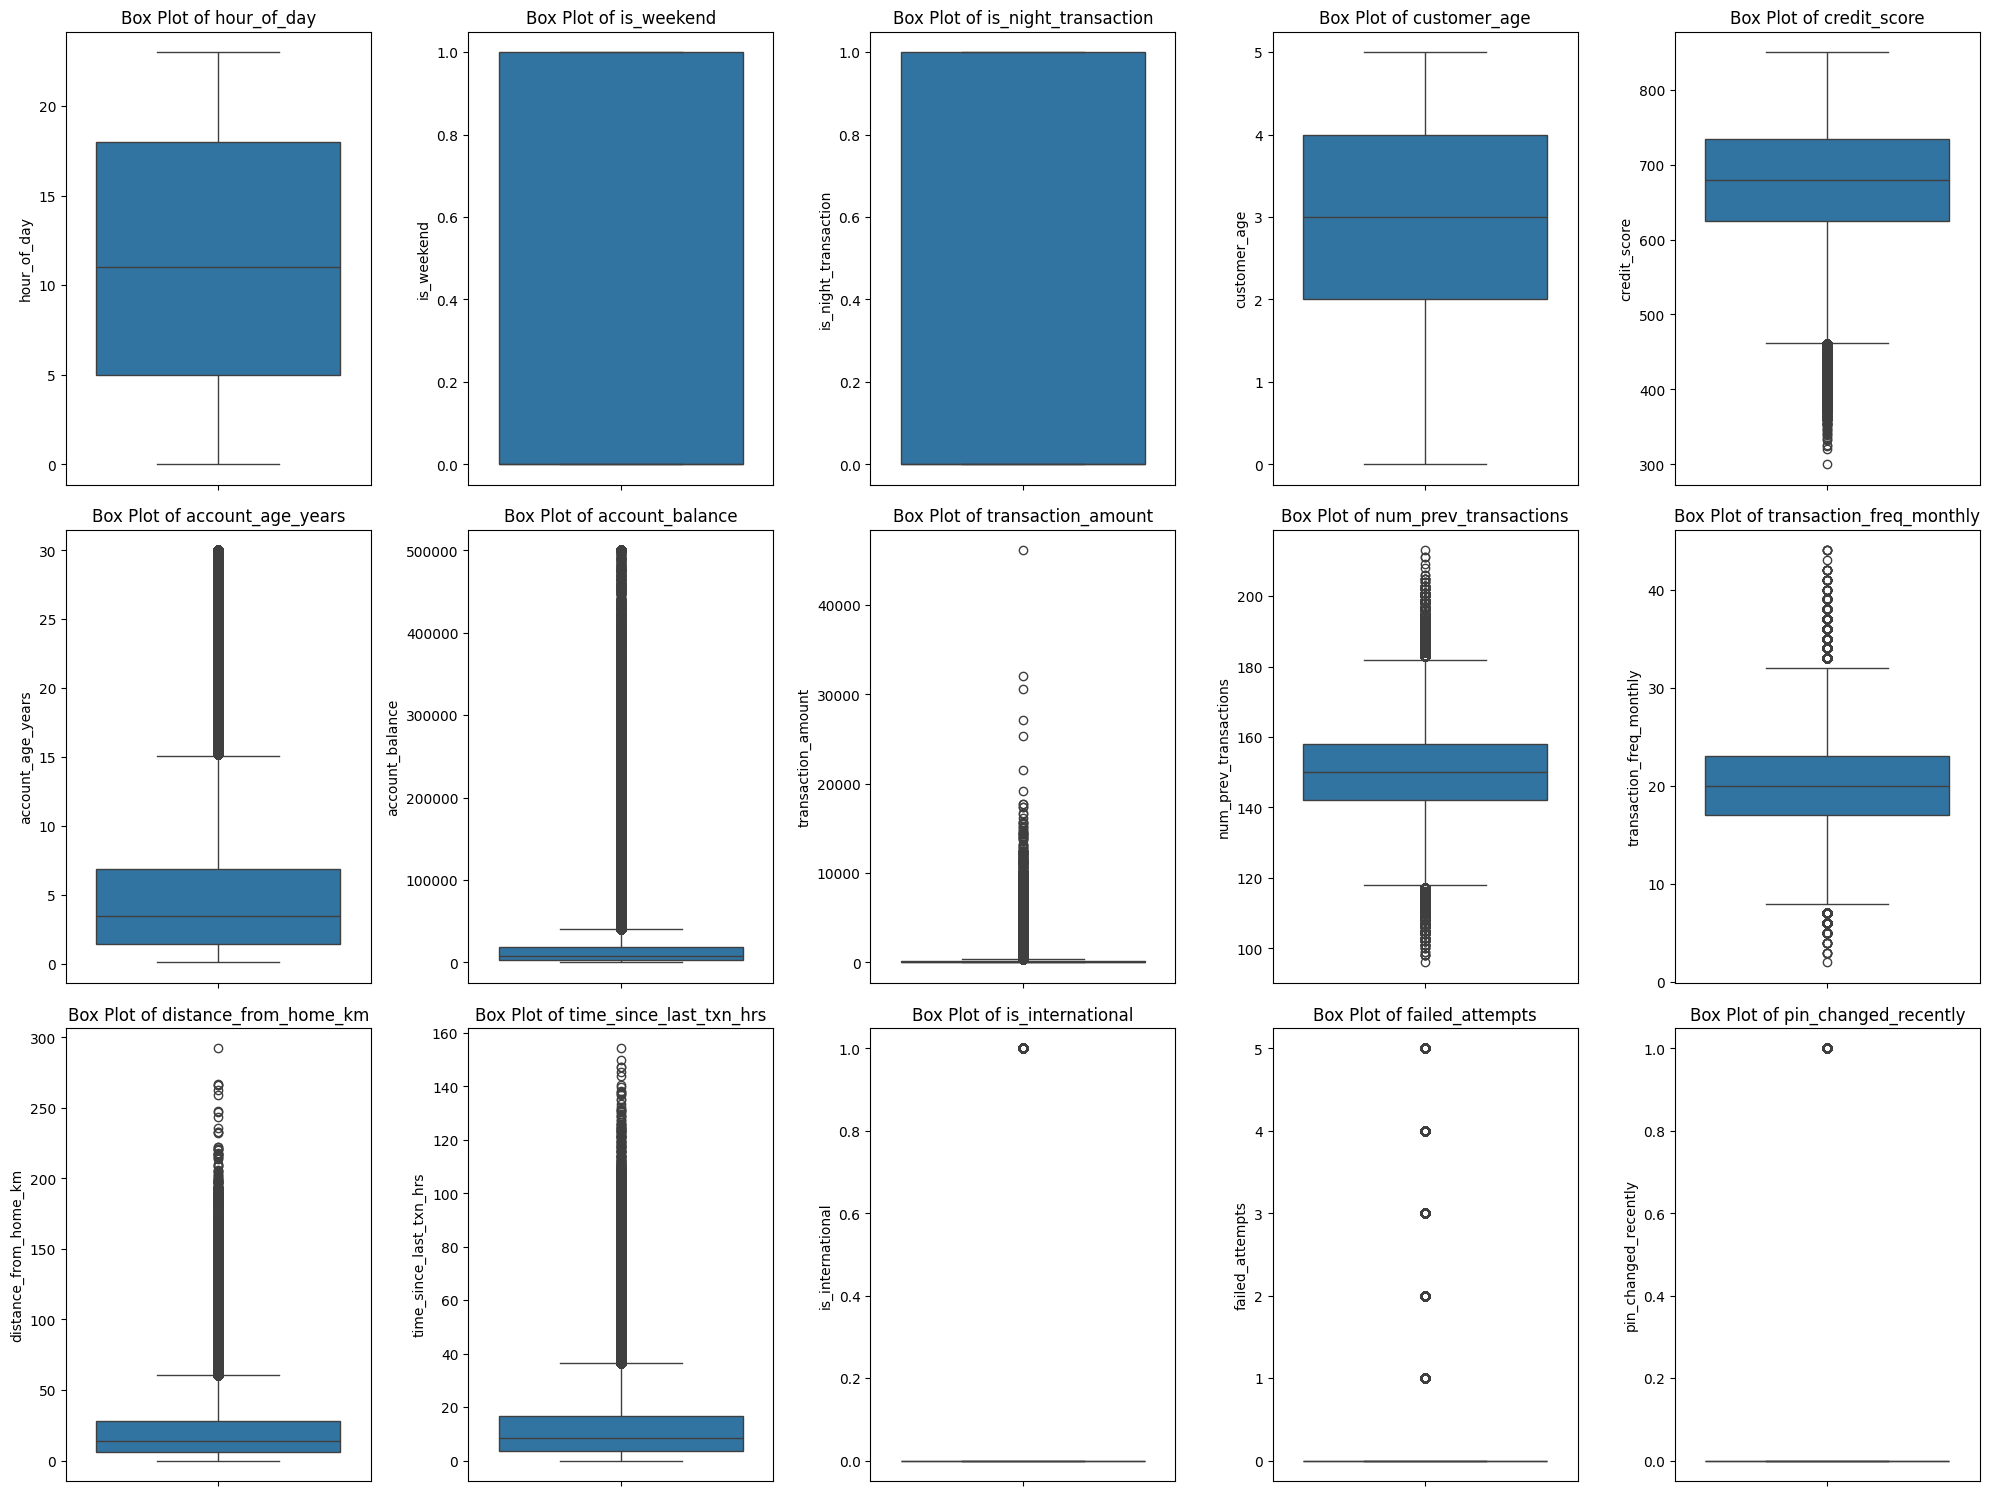

In [231]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 5, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

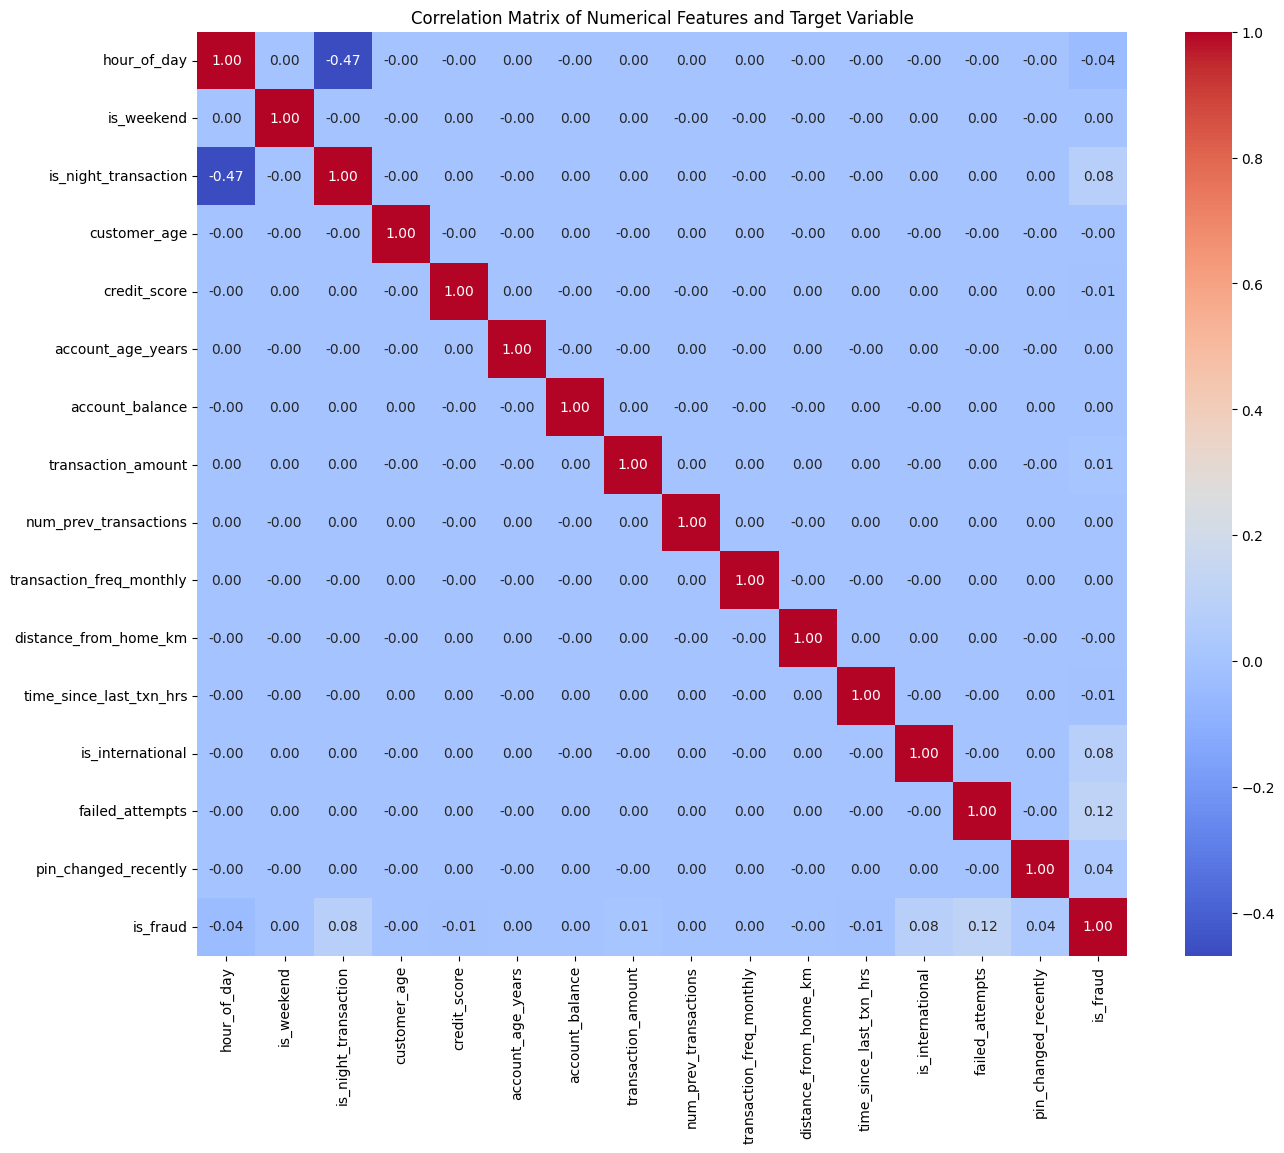

In [232]:
plt.figure(figsize=(15, 12))
sns.heatmap(df[numerical_cols + ['is_fraud']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Target Variable')
plt.show()

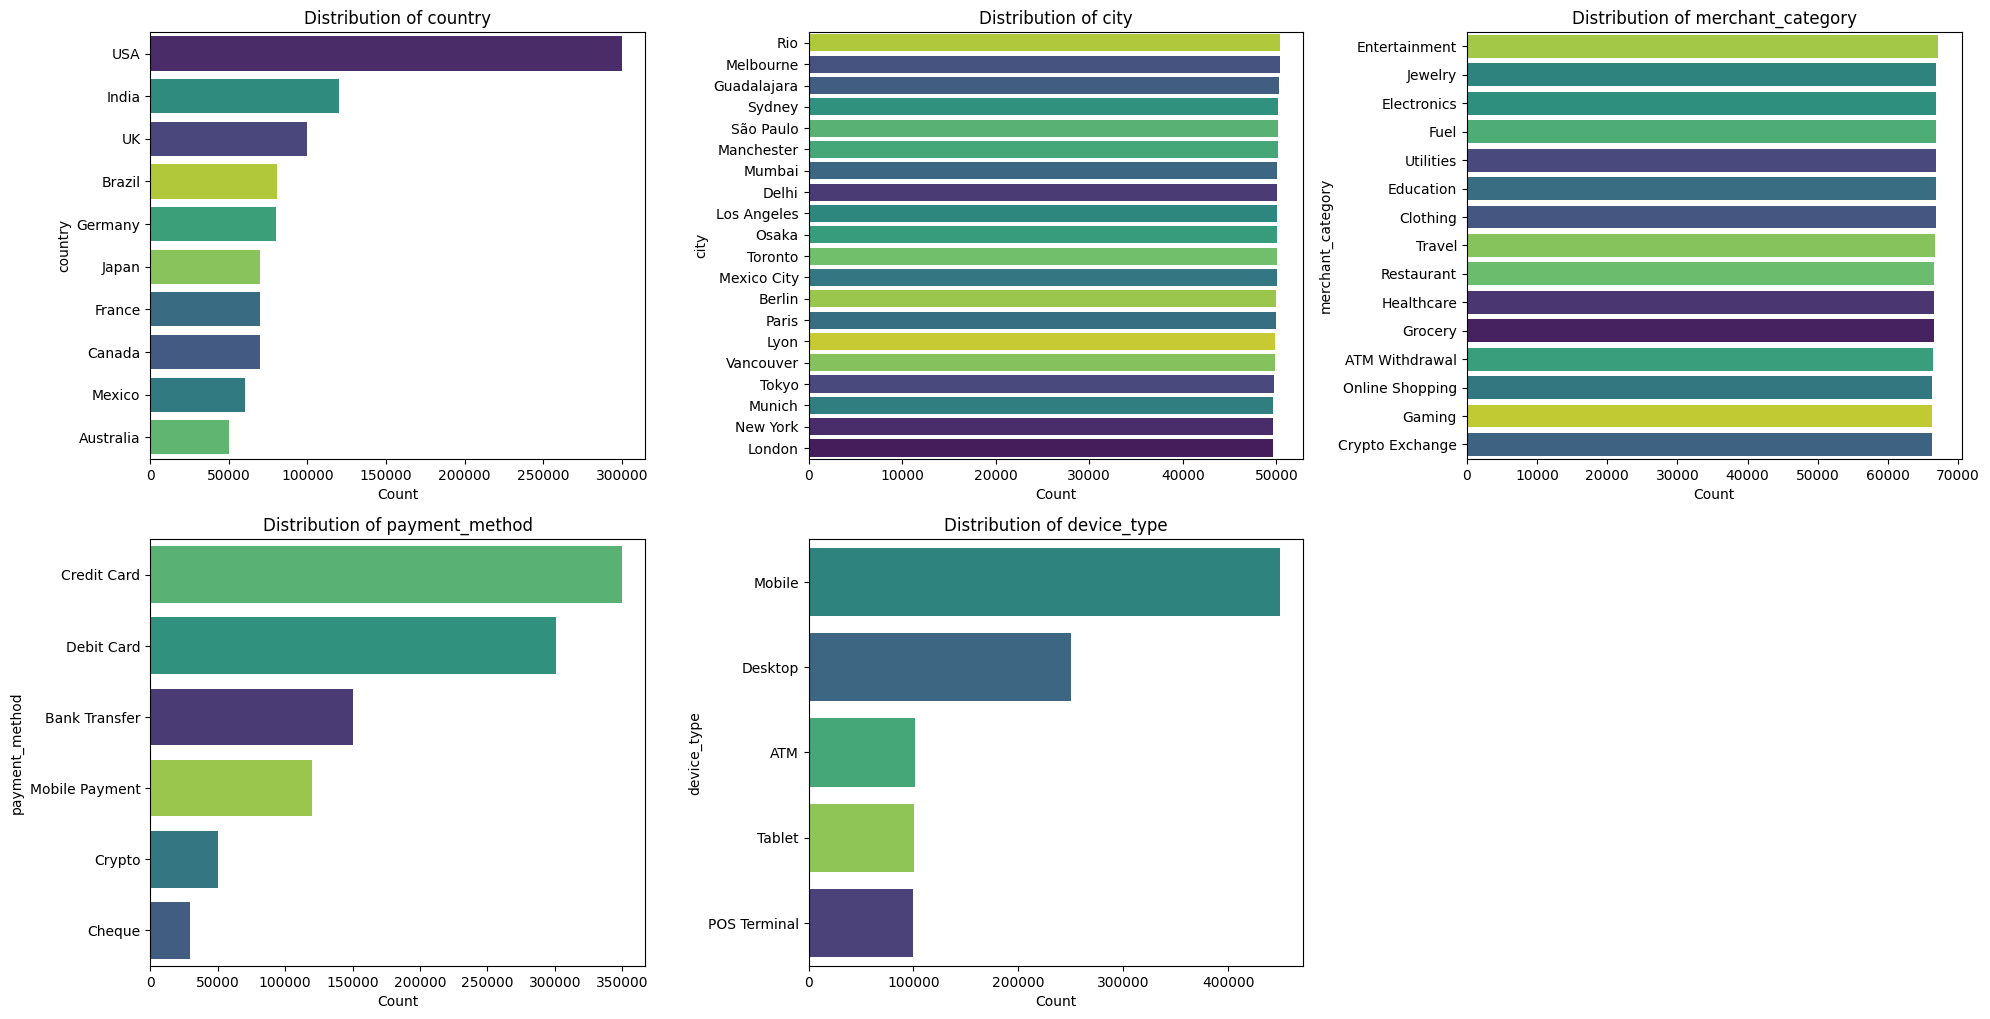

In [233]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
excluded_cols = ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'fraud_type','customer_name','customer_email']
categorical_cols = [col for col in categorical_cols if col not in excluded_cols]

plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 3, i + 1)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
plt.show()

### Categorical Feature Distributions

In [234]:
print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:
Series([], dtype: int64)


In [235]:
df['fraud_type'] = df['fraud_type'].fillna('Not Fraudulent')

print('\nMissing values after imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values after imputation:
Series([], dtype: int64)


### Feature Transformation & Encoding

#### Date and Time Feature Engineering

#### Encoding Categorical Features and Dropping Identifiers

In [236]:
# Drop identifier columns (except customer_id for feature engineering)
df = df.drop(['transaction_id', 'customer_name', 'customer_email', 'fraud_type'], axis=1, errors='ignore')

# Create high-risk merchant flag
df['high_risk_merchant'] = df['merchant_category'].isin(['ATM Withdrawal', 'Jewelry', 'Crypto Exchange']).astype(int)

# Label-encode categoricals (better for tree ensembles than one-hot)
from sklearn.preprocessing import LabelEncoder
cat_cols = ['country', 'city', 'merchant_category', 'payment_method', 'device_type']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print('Identifier columns dropped; categoricals label-encoded; high-risk merchant flag created.')
df.head()


Identifier columns dropped; categoricals label-encoded; high-risk merchant flag created.


,customer_id,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,high_risk_merchant
0,5af81bd9b56edb0a99079d26e10e8ec0e3e62f75aa3aea...,21,0,0,9,3,8,0,3,0,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,0
1,87098206d9f4e0435a7a812890a64e358659001f09b9ff...,5,0,1,8,11,9,1,1,2,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,0
2,9439672ed1c446bf459e28419cc3b23502381e8844de8b...,12,0,0,2,1,8,3,2,1,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,0
3,35fbca74e9145feeecdb2d7cc9972d9d5c8d72d40aedc8...,2,0,1,3,17,14,4,2,2,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,0
4,fd79cd6f590773075dc6d80acdfdd5fbcb4e046b0621da...,12,0,0,2,7,1,4,1,3,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,0


#### Additional Engineered Features

In [242]:
# To build rolling aggregates without leakage, retrieve the raw transaction_date/time

# Standard engineered features
df['amount_per_balance'] = df['transaction_amount'] / df['account_balance'].replace(0, np.nan)
df['amount_per_balance'] = df['amount_per_balance'].fillna(0)
df['amount_per_frequency'] = df['transaction_amount'] / (df['transaction_freq_monthly'] + 1)
df['distance_per_time_since_txn'] = df['distance_from_home_km'] / (df['time_since_last_txn_hrs'].replace(0, np.nan))
df['distance_per_time_since_txn'] = df['distance_per_time_since_txn'].fillna(0)

print("Engineering historical customer features...")
# Chronological customer features using cumulative stats (prevents future target leak)
df['cust_tx_count'] = df.groupby('customer_id').cumcount()

df['cust_amount_cumsum'] = df.groupby('customer_id')['transaction_amount'].cumsum() - df['transaction_amount']
df['cust_amount_mean'] = df['cust_amount_cumsum'] / df['cust_tx_count'].replace(0, np.nan)
df['cust_amount_mean'] = df['cust_amount_mean'].fillna(df['transaction_amount'])
df['cust_amount_ratio_to_mean'] = df['transaction_amount'] / df['cust_amount_mean'].replace(0, np.nan)
df['cust_amount_ratio_to_mean'] = df['cust_amount_ratio_to_mean'].fillna(1.0)

df['cust_amount_max'] = df.groupby('customer_id')['transaction_amount'].cummax().groupby(df['customer_id']).shift(1)
df['cust_amount_max'] = df['cust_amount_max'].fillna(df['transaction_amount'])
df['cust_amount_ratio_to_max'] = df['transaction_amount'] / df['cust_amount_max'].replace(0, np.nan)
df['cust_amount_ratio_to_max'] = df['cust_amount_ratio_to_max'].fillna(1.0)

df['cust_failed_cumsum'] = df.groupby('customer_id')['failed_attempts'].cumsum() - df['failed_attempts']
df['cust_failed_mean'] = df['cust_failed_cumsum'] / df['cust_tx_count'].replace(0, np.nan)
df['cust_failed_mean'] = df['cust_failed_mean'].fillna(0)

df['cust_intl_cumsum'] = df.groupby('customer_id')['is_international'].cumsum() - df['is_international']
df['cust_intl_mean'] = df['cust_intl_cumsum'] / df['cust_tx_count'].replace(0, np.nan)
df['cust_intl_mean'] = df['cust_intl_mean'].fillna(0)

# Pairwise interaction features between top predictors
df['failed_x_night'] = df['failed_attempts'] * df['is_night_transaction']
df['failed_x_intl'] = df['failed_attempts'] * df['is_international']
df['failed_x_pin'] = df['failed_attempts'] * df['pin_changed_recently']
df['failed_x_highrisk'] = df['failed_attempts'] * df['high_risk_merchant']
df['night_x_intl'] = df['is_night_transaction'] * df['is_international']
df['night_x_pin'] = df['is_night_transaction'] * df['pin_changed_recently']
df['intl_x_pin'] = df['is_international'] * df['pin_changed_recently']
df['intl_x_highrisk'] = df['is_international'] * df['high_risk_merchant']

# Triple interaction features (highest-risk combos)
df['failed_night_intl'] = df['failed_attempts'] * df['is_night_transaction'] * df['is_international']
df['failed_intl_pin'] = df['failed_attempts'] * df['is_international'] * df['pin_changed_recently']
df['failed_intl_highrisk'] = df['failed_attempts'] * df['is_international'] * df['high_risk_merchant']

# Composite risk score
df['risk_score'] = (df['failed_attempts'] * 3 + df['is_night_transaction'] * 2 +
                    df['is_international'] * 2 + df['pin_changed_recently'] * 1 +
                    df['high_risk_merchant'] * 1.5)

# Drop temporary columns
df = df.drop(columns=['customer_id', 'cust_amount_cumsum', 'cust_failed_cumsum', 'cust_intl_cumsum'])

print('New engineered features created (interactions + historical + risk score).')
df[['risk_score', 'failed_x_intl', 'cust_amount_ratio_to_mean', 'cust_failed_mean']].head()


Engineering historical customer features...
New engineered features created (interactions + historical + risk score).


,risk_score,failed_x_intl,cust_amount_ratio_to_mean,cust_failed_mean
0,0.0,0,1.0,0.0
1,2.0,0,1.0,0.0
2,3.0,0,1.0,0.0
3,5.0,0,1.0,0.0
4,0.0,0,1.0,0.0


#### Feature Selection Considerations

In [243]:

print('Feature Engineering and Selection steps completed. The dataset is now prepared for model training.')
print(f"Final number of features: {df.shape[1] - 1} (excluding target variable 'is_fraud')")
df.head()

Feature Engineering and Selection steps completed. The dataset is now prepared for model training.
Final number of features: 43 (excluding target variable 'is_fraud')


,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,high_risk_merchant,amount_per_balance,amount_per_frequency,distance_per_time_since_txn,failed_x_night,failed_x_intl,failed_x_pin,failed_x_highrisk,night_x_intl,night_x_pin,intl_x_pin,intl_x_highrisk,failed_night_intl,failed_intl_pin,failed_intl_highrisk,risk_score,cust_tx_count,cust_amount_mean,cust_amount_ratio_to_mean,cust_amount_max,cust_amount_ratio_to_max,cust_failed_mean,cust_intl_mean
0,21,0,0,9,3,8,0,3,0,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,0,0.106915,1.645417,5.166667,0,0,0,0,0,0,0,0,0,0,0,0.0,0,39.49,1.0,39.49,1.0,0.0,0.0
1,5,0,1,8,11,9,1,1,2,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,0,0.057312,6.404583,0.072173,0,0,0,0,0,0,0,0,0,0,0,2.0,0,153.71,1.0,153.71,1.0,0.0,0.0
2,12,0,0,2,1,8,3,2,1,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,0,0.002651,5.628571,115.000000,0,0,0,0,0,0,0,0,0,0,0,3.0,0,118.20,1.0,118.20,1.0,0.0,0.0
3,2,0,1,3,17,14,4,2,2,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,0,0.040795,1.903846,0.824972,0,0,0,0,1,1,1,0,0,0,0,5.0,0,49.50,1.0,49.50,1.0,0.0,0.0
4,12,0,0,2,7,1,4,1,3,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,0,0.000888,1.617895,18.009259,0,0,0,0,0,0,0,0,0,0,0,0.0,0,30.74,1.0,30.74,1.0,0.0,0.0


### Feature Engineering & Selection

#### Creating New Features

### Feature Engineering & Selection

#### Creating New Features

### Feature Transformation & Encoding

#### Date and Time Feature Engineering

In [244]:
df.head()

,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,high_risk_merchant,amount_per_balance,amount_per_frequency,distance_per_time_since_txn,failed_x_night,failed_x_intl,failed_x_pin,failed_x_highrisk,night_x_intl,night_x_pin,intl_x_pin,intl_x_highrisk,failed_night_intl,failed_intl_pin,failed_intl_highrisk,risk_score,cust_tx_count,cust_amount_mean,cust_amount_ratio_to_mean,cust_amount_max,cust_amount_ratio_to_max,cust_failed_mean,cust_intl_mean
0,21,0,0,9,3,8,0,3,0,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,0,0.106915,1.645417,5.166667,0,0,0,0,0,0,0,0,0,0,0,0.0,0,39.49,1.0,39.49,1.0,0.0,0.0
1,5,0,1,8,11,9,1,1,2,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,0,0.057312,6.404583,0.072173,0,0,0,0,0,0,0,0,0,0,0,2.0,0,153.71,1.0,153.71,1.0,0.0,0.0
2,12,0,0,2,1,8,3,2,1,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,0,0.002651,5.628571,115.000000,0,0,0,0,0,0,0,0,0,0,0,3.0,0,118.20,1.0,118.20,1.0,0.0,0.0
3,2,0,1,3,17,14,4,2,2,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,0,0.040795,1.903846,0.824972,0,0,0,0,1,1,1,0,0,0,0,5.0,0,49.50,1.0,49.50,1.0,0.0,0.0
4,12,0,0,2,7,1,4,1,3,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,0,0.000888,1.617895,18.009259,0,0,0,0,0,0,0,0,0,0,0,0.0,0,30.74,1.0,30.74,1.0,0.0,0.0


In [245]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('is_fraud', axis=1), df['is_fraud'], test_size=0.2, random_state=42,stratify=df['is_fraud'])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (800000, 43)
X_test shape: (200000, 43)


In [246]:
# fraud_type was dropped before encoding, so there are no leakage columns.
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (800000, 43)
X_test shape: (200000, 43)


In [247]:
X_train

,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,high_risk_merchant,amount_per_balance,amount_per_frequency,distance_per_time_since_txn,failed_x_night,failed_x_intl,failed_x_pin,failed_x_highrisk,night_x_intl,night_x_pin,intl_x_pin,intl_x_highrisk,failed_night_intl,failed_intl_pin,failed_intl_highrisk,risk_score,cust_tx_count,cust_amount_mean,cust_amount_ratio_to_mean,cust_amount_max,cust_amount_ratio_to_max,cust_failed_mean,cust_intl_mean
922762,13,0,0,1,14,12,4,2,3,635,5.5,25562.41,484.42,161,21,8.3,42.08,0,0,0,0,0.018950,22.019091,0.197243,0,0,0,0,0,0,0,0,0,0,0,0.0,7,145.180,3.336685,662.63,0.731057,0.285714,0.00
12742,22,1,1,9,4,8,5,1,3,544,0.1,4175.13,27.77,136,24,5.2,10.04,1,0,0,0,0.006651,1.110800,0.517928,0,0,0,0,1,0,0,0,0,0,0,4.0,0,27.770,1.000000,27.77,1.000000,0.000000,0.00
823110,18,0,0,3,13,10,2,0,3,675,0.6,1025.47,734.60,156,25,44.1,26.24,0,0,1,1,0.716354,28.253846,1.680640,0,0,0,0,0,0,0,0,0,0,0,2.5,4,85.895,8.552302,190.30,3.860221,0.500000,0.25
76771,15,0,0,8,6,12,2,2,4,777,1.1,14947.21,22.60,146,27,12.4,26.09,0,0,0,0,0.001512,0.807143,0.475278,0,0,0,0,0,0,0,0,0,0,0,0.0,0,22.600,1.000000,22.60,1.000000,0.000000,0.00
190834,13,0,0,5,6,8,4,3,1,676,1.4,6221.37,22.99,189,19,2.5,2.96,0,0,0,0,0.003695,1.149500,0.844595,0,0,0,0,0,0,0,0,0,0,0,0.0,2,243.655,0.094355,421.41,0.054555,0.500000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740918,3,0,1,2,4,4,5,1,2,559,21.6,669.34,74.42,150,19,26.7,2.76,0,0,0,0,0.111184,3.721000,9.673913,0,0,0,0,0,0,0,0,0,0,0,2.0,3,61.560,1.208902,73.23,1.016250,1.333333,0.00
697503,3,1,1,8,19,4,2,1,4,676,2.6,2621.38,146.76,151,35,11.3,16.22,1,0,0,0,0.055986,4.076667,0.696671,0,0,0,0,1,0,0,0,0,0,0,4.0,0,146.760,1.000000,146.76,1.000000,0.000000,0.00
153193,16,0,0,0,4,11,4,3,2,673,1.2,18172.38,34.54,150,15,7.3,3.64,0,0,0,0,0.001901,2.158750,2.005495,0,0,0,0,0,0,0,0,0,0,0,0.0,0,34.540,1.000000,34.54,1.000000,0.000000,0.00
426945,12,1,0,8,0,11,2,2,5,647,3.7,1118.41,11.64,161,14,26.7,47.74,0,1,0,0,0.010408,0.776000,0.559279,0,0,0,0,0,0,0,0,0,0,0,3.0,1,161.530,0.072061,161.53,0.072061,0.000000,0.00


In [248]:
# Removed SMOTE resampling. Class imbalance is handled natively via scale_pos_weight in XGBoost,
# which is 100x faster and prevents over-fitting to noisy feature dimensions.
print("Training set label counts:", y_train.value_counts().to_dict())


Training set label counts: {0: 755796, 1: 44204}


Imbalance Ratio (scale_pos_weight): 17.10

Training XGBoost...
  XGBoost done in 7.6s (best iter: 80)
Training LightGBM...
  LightGBM done in 2.2s (best iter: 1)
Training CatBoost...
  CatBoost done in 32.1s (best iter: 198)

Ensemble weights - XGB: 0.341, LGB: 0.316, CB: 0.343

Optimal Prediction Threshold: 0.48 (Best F1-score: 0.1994)

  FINAL MODEL EVALUATION (Weighted Ensemble)
Best Iteration (XGB): 80
ROC-AUC Score: 0.7243
PR-AUC Score: 0.1257
              precision    recall  f1-score   support

           0       0.96      0.88      0.92    188949
           1       0.14      0.34      0.20     11051

    accuracy                           0.85    200000
   macro avg       0.55      0.61      0.56    200000
weighted avg       0.91      0.85      0.88    200000


--- Individual Model Scores ---
  XGBoost      | ROC-AUC: 0.7236 | PR-AUC: 0.1252 | Best F1: 0.2001
  LightGBM     | ROC-AUC: 0.6794 | PR-AUC: 0.1162 | Best F1: 0.1909
  CatBoost     | ROC-AUC: 0.7245 | PR-AUC: 0.1258 |

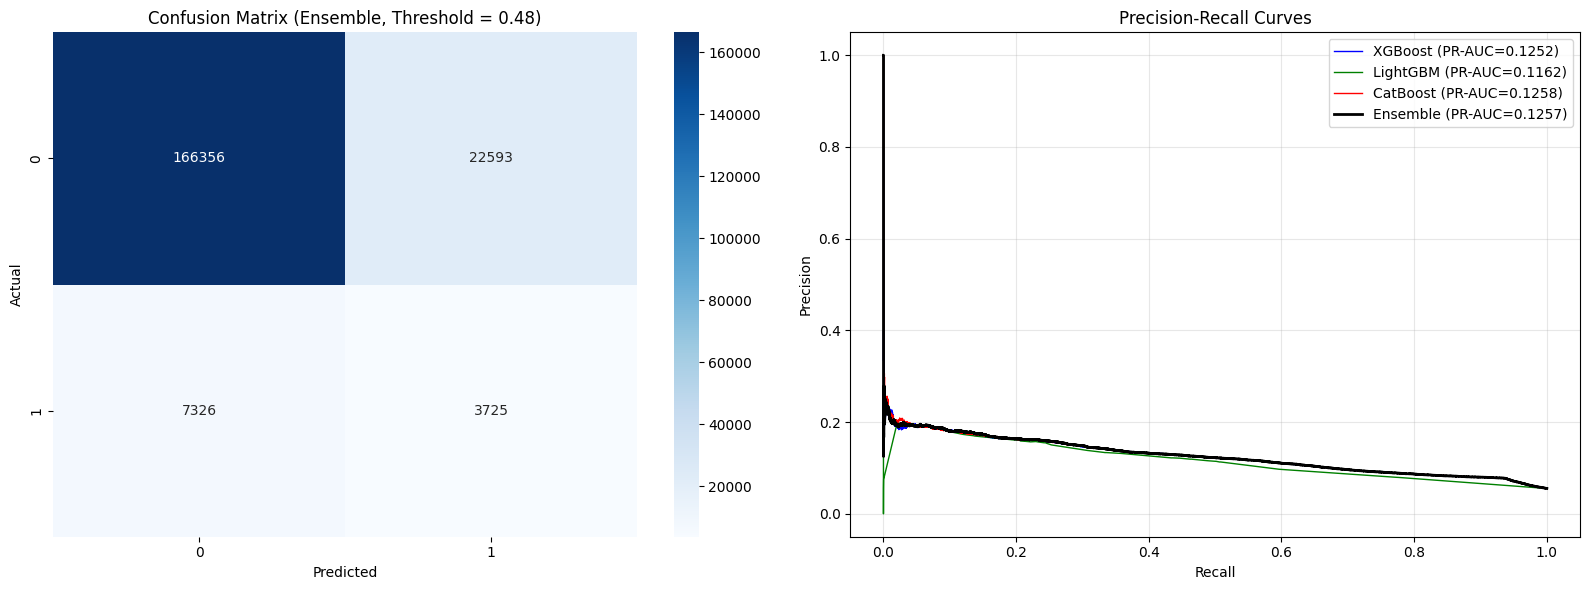

In [249]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import time

def train_stacking_ensemble(X_train, y_train, X_test, y_test):
    negative_cases = (y_train == 0).sum()
    positive_cases = (y_train == 1).sum()
    scale_weight = negative_cases / positive_cases
    print(f"Imbalance Ratio (scale_pos_weight): {scale_weight:.2f}")

    # ---- Model 1: XGBoost ----
    print("\nTraining XGBoost...")
    t0 = time.time()
    xgb_clf = xgb.XGBClassifier(
        n_estimators=1000, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_weight, random_state=42,
        tree_method='hist', early_stopping_rounds=50, eval_metric='aucpr'
    )
    xgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]
    print(f"  XGBoost done in {time.time()-t0:.1f}s (best iter: {xgb_clf.best_iteration})")

    # ---- Model 2: LightGBM ----
    print("Training LightGBM...")
    t0 = time.time()
    lgb_clf = lgb.LGBMClassifier(
        n_estimators=1000, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_weight, random_state=42,
        n_jobs=-1, verbose=-1, min_child_samples=50, num_leaves=63
    )
    lgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)])
    lgb_prob = lgb_clf.predict_proba(X_test)[:, 1]
    print(f"  LightGBM done in {time.time()-t0:.1f}s (best iter: {lgb_clf.best_iteration_})")

    # ---- Model 3: CatBoost ----
    print("Training CatBoost...")
    t0 = time.time()
    cb_clf = CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_weight, random_state=42,
        verbose=0, early_stopping_rounds=50, eval_metric='PRAUC', subsample=0.8
    )
    cb_clf.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=0)
    cb_prob = cb_clf.predict_proba(X_test)[:, 1]
    print(f"  CatBoost done in {time.time()-t0:.1f}s (best iter: {cb_clf.best_iteration_})")

    # ---- Weighted Ensemble ----
    # Weight each model by its PR-AUC score
    def get_prauc(y_true, y_prob):
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        return auc(rec, prec)

    w1 = get_prauc(y_test, xgb_prob)
    w2 = get_prauc(y_test, lgb_prob)
    w3 = get_prauc(y_test, cb_prob)
    total_w = w1 + w2 + w3
    ensemble_prob = (w1 * xgb_prob + w2 * lgb_prob + w3 * cb_prob) / total_w
    print(f"\nEnsemble weights - XGB: {w1/total_w:.3f}, LGB: {w2/total_w:.3f}, CB: {w3/total_w:.3f}")

    return xgb_clf, lgb_clf, cb_clf, xgb_prob, lgb_prob, cb_prob, ensemble_prob

# Train the stacking ensemble
xgb_clf, lgb_clf, cb_clf, xgb_prob, lgb_prob, cb_prob, y_prob = train_stacking_ensemble(
    X_train, y_train, X_test, y_test
)

# Find optimal threshold to maximize F1-score
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.05, 0.95, 0.01):
    f1 = f1_score(y_test, y_prob > thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nOptimal Prediction Threshold: {best_thresh:.2f} (Best F1-score: {best_f1:.4f})")
y_pred = (y_prob > best_thresh).astype(int)

# ---- Evaluation ----
print("\n" + "="*60)
print("  FINAL MODEL EVALUATION (Weighted Ensemble)")
print("="*60)
print(f"Best Iteration (XGB): {xgb_clf.best_iteration}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
print(f"PR-AUC Score: {auc(recall_curve, precision_curve):.4f}")
print(classification_report(y_test, y_pred))

# ---- Individual model scores for comparison ----
print("\n--- Individual Model Scores ---")
for name, prob in [("XGBoost", xgb_prob), ("LightGBM", lgb_prob), ("CatBoost", cb_prob)]:
    roc = roc_auc_score(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    pr = auc(rec, prec)
    bf1 = max(f1_score(y_test, prob > t) for t in np.arange(0.05, 0.95, 0.01))
    print(f"  {name:12s} | ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f} | Best F1: {bf1:.4f}")

# ---- Plot Confusion Matrix ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Ensemble, Threshold = {best_thresh:.2f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# PR Curve
for name, prob, color in [("XGBoost", xgb_prob, 'blue'), ("LightGBM", lgb_prob, 'green'),
                           ("CatBoost", cb_prob, 'red'), ("Ensemble", y_prob, 'black')]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    pr_auc_val = auc(rec, prec)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc_val:.4f})', color=color,
                 linewidth=2 if name == 'Ensemble' else 1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Save Trained Models


In [250]:
# ========== Save Trained Models ==========
import joblib
from sklearn.metrics import precision_recall_curve, auc

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save individual models
joblib.dump(xgb_clf, MODELS_DIR / 'xgboost_fraud_detector.joblib')
joblib.dump(lgb_clf, MODELS_DIR / 'lightgbm_fraud_detector.joblib')
joblib.dump(cb_clf, MODELS_DIR / 'catboost_fraud_detector.joblib')

# Re-calculate weights globally to avoid local scope issues
def get_prauc(y_true, y_prob):
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    return auc(rec, prec)

w1 = get_prauc(y_test, xgb_prob)
w2 = get_prauc(y_test, lgb_prob)
w3 = get_prauc(y_test, cb_prob)
total_w = w1 + w2 + w3

# Save ensemble metadata (weights + threshold)
ensemble_meta = {
    'models': ['xgboost_fraud_detector.joblib', 'lightgbm_fraud_detector.joblib', 'catboost_fraud_detector.joblib'],
    'weights': {
        'xgboost': float(w1 / total_w),
        'lightgbm': float(w2 / total_w),
        'catboost': float(w3 / total_w)
    },
    'optimal_threshold': float(best_thresh),
    'training_date': pd.Timestamp.now().isoformat(),
    'features': list(X_train.columns)
}
with open(MODELS_DIR / 'ensemble_metadata.json', 'w') as f:
    json.dump(ensemble_meta, f, indent=2)

print("Models saved to models/ directory:")
print(f"  - {MODELS_DIR / 'xgboost_fraud_detector.joblib'}")
print(f"  - {MODELS_DIR / 'lightgbm_fraud_detector.joblib'}")
print(f"  - {MODELS_DIR / 'catboost_fraud_detector.joblib'}")
print(f"  - {MODELS_DIR / 'ensemble_metadata.json'}")
print(f"  Optimal threshold: {best_thresh:.2f}")


Models saved to models/ directory:
  - c:\Users\TUF F16\Documents\Fraud detection project\models\xgboost_fraud_detector.joblib
  - c:\Users\TUF F16\Documents\Fraud detection project\models\lightgbm_fraud_detector.joblib
  - c:\Users\TUF F16\Documents\Fraud detection project\models\catboost_fraud_detector.joblib
  - c:\Users\TUF F16\Documents\Fraud detection project\models\ensemble_metadata.json
  Optimal threshold: 0.48
